In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle, copy
from collections import defaultdict
from Networkmodel import NetworkModel_org, HopField

In [35]:
class NetworkModel(NetworkModel_org):
    def task_condition(self):
        self.HFregister = dict()
        self.actdict = {1: [2], 2: [3,4], 3: [2], 4: [1]}  
        self.initial = 1
        self.terminal = [4]
        self.stmdict = {1: [1], 2: [2], 3: [3], 4:[4]}
        self.cortex_calc = [1]
        self.stmindex = {1:0, 2:0, 3:0, 4:0}
        self.swblock = 30
        for key,val in self.stmdict.items():
            for s in val:
                tmp = np.zeros(self.nstm)
                tmp[np.sort(np.random.choice(len(tmp), int(len(tmp)/2), replace = False))] = 1  
                self.HFregister[s] = tmp
                
    def check_rwd(self, result, count):
        if not result[-1]["cond"] in self.terminal:
            return 0
        swmode = np.mod(np.floor(count/self.swblock),2)
        tmp1 = sum([result[i]["infcond"] for i in range(len(result))], [])
        tmp2 = [result[i]["cond"] for i in range(len(result))]
        cnt1,cnt2 = len(np.where(np.array(tmp1)==3)[0]),len(np.where(np.array(tmp2)==3)[0])
        #if count < self.swblock:
            #return int(cnt1 + cnt2 == 0) #0 lap
        if count < self.swblock*1:
            return int(0 < cnt1 < 3 or 0 < cnt2 < 2) #1 lap 
        elif count < self.swblock*2:
            return int(2 < cnt1 or 1 < cnt2)  # 2 laps or more
        elif count < self.swblock*3:
            return int(0 < cnt1 < 3 or 0 < cnt2 < 2) #1 lap 
        elif count < self.swblock*4:
            return int(2 < cnt1 or 1 < cnt2)  # 2 laps or more
        elif count < self.swblock*5:
            return int(0 < cnt1 < 3 or 0 < cnt2 < 2) #1 lap 

In [36]:
allresult = dict()
x = 0

In [37]:
hp = NetworkModel(200,1000,300,1200,8)
result = []
HCprev = []
cond = None
for i in range(150):
    result_,HCprev,cond = hp.process(i, HCprev, cond, verbose = True)
    result.append(result_)
#allresult[x] = result
x += 1

trial 0 stmindex 0 HCprev []
HCprev []
think 0-0 [127]
plan 1 [] 2
init 1 2
memo 1 0
HF2HC [128] 1-0
HC2HF [128] 1-0
pkup [128] 1-0
choose [1. 2.] [128  37]
HF2HC [128] 1-0
HC2HF [128] 1-0
HCprev [array([37], dtype=int64)]
think 0-0 [82]
plan 2 [] 4
init 2 4
memo 2 0
HF2HC [137] 2-0
HC2HF [137] 2-0
pkup [137] 2-0
choose [2. 4.] [137  46]
HC2HF [37] 2-0
HF2HC [137] 2-0
HC2HF [137] 2-0
HCprev [array([46], dtype=int64)]
think 0-0 [262]
plan 4 [] 1
init 4 1
memo 4 0
HF2HC [169] 4-0
HC2HF [169] 4-0
pkup [169] 4-0
choose [4. 1.] [169 199]
HC2HF [46] 4-0
HF2HC [169] 4-0
HC2HF [169] 4-0
check trans [4.0] {}
['c:1', 'n:2.0', 'e:0.0', 'i:[1.0]', 'c:[0.0]', 'p:[1.0, 2.0]', 'H:[128  37]', 'a:1-0', 'r:0']
['c:2', 'n:4.0', 'e:0.0', 'i:[2.0]', 'c:[0.0]', 'p:[2.0, 4.0]', 'H:[ 37 137  46]', 'a:2-0', 'r:0']
['c:4', 'n:1', 'e:0.0', 'i:[4.0, 1.0]', 'c:[0.0, -1.0]', 'p:[4.0, 1.0]', 'H:[ 46 169 199]', 'a:4-0', 'r:0', "p:['1-0', '2-0', '4-0']"]

trial 1 stmindex 0 HCprev 199
HCprev [array([199], dtype=int64)

tested ['3.0-0', '2.0-0', '2.0-1', '4.0-1', '1.0-0']
check trans [1.0, 2.0, 3.0, 2.0, 4.0, 1.0] {}
['c:1', 'n:4.0', 'e:0.8031255956592774', 'i:[1.0, 2.0, 3.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0, 1.0, 1.0]', 'p:[1.0, 2.0, 3.0, 2.0, 4.0]', 'H:[106 128  37 137   9 103 218 196 256  56 106]', 'a:1-0', 'r:0']
['c:4', 'n:1', 'e:0.8031255956592774', 'i:[1.0, 2.0, 3.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0, 1.0, 1.0]', 'p:[1.0, 2.0, 3.0, 2.0, 4.0]', 'H:[106 128  37 137   9 103 218 196 256  56 106]', 'a:4-1', 'r:1', "p:['1-0', '2-0', '4-0', '3-0', '2-1', '4-1']"]

trial 12 stmindex 0 HCprev 106
HCprev [array([106], dtype=int64)]
think 1-0 [128]
choose [1. 2. 3. 2. 4.] [128  37 137   9 103 218 196 256  56 106]
HC2HF [106] 1-0
HF2HC [128] 1-0
HC2HF [128] 1-0
tested ['3.0-0', '2.0-0', '2.0-1', '4.0-1', '1.0-0']
check trans [1.0, 2.0, 3.0, 2.0, 4.0, 1.0] {}
['c:1', 'n:4.0', 'e:0.8326567563103858', 'i:[1.0, 2.0, 3.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0, 1.0, 1.0]', 'p:[1.0, 2.0, 3.0, 2.0, 4.0]', 'H:[106 128  37 137   9

check trans [1.0, 2.0, 3.0, 2.0, 4.0, 1.0] {}
['c:1', 'n:4.0', 'e:0.9797672825268142', 'i:[1.0, 2.0, 3.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0, 1.0, 1.0]', 'p:[1.0, 2.0, 3.0, 2.0, 4.0]', 'H:[106 128  37 137   9 103 218 196 256  56 106]', 'a:1-0', 'r:0']
['c:4', 'n:1', 'e:0.9797672825268142', 'i:[1.0, 2.0, 3.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0, 1.0, 1.0]', 'p:[1.0, 2.0, 3.0, 2.0, 4.0]', 'H:[106 128  37 137   9 103 218 196 256  56 106]', 'a:4-1', 'r:1', "p:['1-0', '2-0', '4-0', '3-0', '2-1', '4-1']"]

trial 26 stmindex 0 HCprev 106
HCprev [array([106], dtype=int64)]
think 1-0 [128]
choose [1. 2. 3. 2. 4.] [128  37 137   9 103 218 196 256  56 106]
HC2HF [106] 1-0
HF2HC [128] 1-0
HC2HF [128] 1-0
tested ['3.0-0', '2.0-0', '2.0-1', '4.0-1', '1.0-0']
check trans [1.0, 2.0, 3.0, 2.0, 4.0, 1.0] {}
['c:1', 'n:4.0', 'e:0.9828021901477921', 'i:[1.0, 2.0, 3.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0, 1.0, 1.0]', 'p:[1.0, 2.0, 3.0, 2.0, 4.0]', 'H:[106 128  37 137   9 103 218 196 256  56 106]', 'a:1-0', 'r:0']
['c:4', '

choose [4. 1.] [169 199]
HC2HF [46] 4-0
HF2HC [169] 4-0
HC2HF [169] 4-0
check trans [1.0, 2.0, 4.0, 1.0] {(4.0, 1.0): 1.0}
['c:1', 'n:4.0', 'e:0.0', 'i:[1.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0]', 'p:[1.0, 2.0, 4.0]', 'H:[199 128  37 137  46]', 'a:1-0', 'r:0']
['c:4', 'n:1', 'e:0.0', 'i:[4.0, 1.0]', 'c:[0.0, -1.0]', 'p:[4.0, 1.0]', 'H:[128  37 137  46 169 199]', 'a:4-0', 'r:0', "p:['1-0', '2-0', '4-0', '3-0', '2-1', '4-1', '3-1', '2-2', '4-2']"]

trial 36 stmindex 0 HCprev 199
HCprev [array([199], dtype=int64)]
think 1-0 [128]
choose [1. 2. 4.] [128  37 137  46]
HC2HF [199] 1-0
HF2HC [128] 1-0
HC2HF [128] 1-0
HCprev [array([128], dtype=int64), array([37], dtype=int64), array([137], dtype=int64), array([46], dtype=int64)]
think 4-0 [169]
choose [4. 1.] [169 199]
HC2HF [46] 4-0
HF2HC [169] 4-0
HC2HF [169] 4-0
check trans [1.0, 2.0, 4.0, 1.0] {(4.0, 1.0): 1.0}
['c:1', 'n:4.0', 'e:0.0', 'i:[1.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0]', 'p:[1.0, 2.0, 4.0]', 'H:[199 128  37 137  46]', 'a:1-0', 'r:0']
['c:

check trans [1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0, 1.0] {(4.0, 1.0): 1.0}
['c:1', 'n:4.0', 'e:0.38587499999999997', 'i:[1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0, 1.0, 1.0, 2.0, 2.0]', 'p:[1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0]', 'H:[175 128  37 137   9 103 218 196 265  93 266 195  92 184 175]', 'a:1-0', 'r:0']
['c:4', 'n:1', 'e:0.38587499999999997', 'i:[1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0, 1.0, 1.0, 2.0, 2.0]', 'p:[1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0]', 'H:[175 128  37 137   9 103 218 196 265  93 266 195  92 184 175]', 'a:4-2', 'r:1', "p:['1-0', '2-0', '4-0', '3-0', '2-1', '4-1', '3-1', '2-2', '4-2']"]

trial 45 stmindex 0 HCprev 175
HCprev [array([175], dtype=int64)]
think 1-0 [128]
choose [1. 2. 3. 2. 3. 2. 4.] [128  37 137   9 103 218 196 265  93 266 195  92 184 175]
HC2HF [175] 1-0
HF2HC [128] 1-0
HC2HF [128] 1-0
check trans [1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0, 1.0] {(4.0, 1.0): 1.0}
['c:1', 'n:4.0', 'e:0.47799375', 'i:[1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0]', 'c

...

choose [1. 2. 3. 2. 3. 2. 4.] [128  37 137   9 103 218 196 265  93 266 195  92 184 175]
HC2HF [207] 1-0
HF2HC [128] 1-0
HC2HF [128] 1-0
tested ['2.0-2', '3.0-0', '2.0-0', '2.0-1', '3.0-1', '4.0-1', '1.0-0', '4.0-2']
check trans [1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0, 1.0] {(4.0, 1.0): 1.0}
['c:1', 'n:4.0', 'e:0.9096410060977227', 'i:[1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0, 1.0, 1.0, 2.0, 2.0]', 'p:[1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0]', 'H:[207 128  37 137   9 103 218 196 265  93 266 195  92 184 175]', 'a:1-0', 'r:0']
['c:4', 'n:1', 'e:0.9096410060977227', 'i:[1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0, 1.0, 1.0, 2.0, 2.0]', 'p:[1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0]', 'H:[207 128  37 137   9 103 218 196 265  93 266 195  92 184 175]', 'a:4-2', 'r:1', "p:['1-0', '2-0', '4-0', '3-0', '2-1', '4-1', '3-1', '2-2', '4-2', '3-2', '2-3', '4-3']"]

trial 101 stmindex 0 HCprev 175
HCprev [array([175], dtype=int64)]
think 1-0 [128]
choose [1. 2. 3. 2. 3. 2. 3. 2. 4.] [128  37 13

choose [1. 2. 3. 2. 3. 2. 3. 2. 4.] [128  37 137   9 103 218 196 265  93 266 195  23 163  70 109  78  71 207]
HC2HF [207] 1-0
HF2HC [128] 1-0
HC2HF [128] 1-0
tested ['2.0-2', '4.0-3', '3.0-0', '2.0-0', '2.0-3', '2.0-1', '3.0-1', '3.0-2', '4.0-1', '1.0-0', '4.0-2']
check trans [1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0, 1.0] {(4.0, 1.0): 1.0}
['c:1', 'n:4.0', 'e:0.7275094749609375', 'i:[1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0, 1.0, 1.0, 2.0, 2.0, 3.0, 3.0]', 'p:[1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0]', 'H:[207 128  37 137   9 103 218 196 265  93 266 195  23 163  70 109  78  71\n 207]', 'a:1-0', 'r:0']
['c:4', 'n:1', 'e:0.7275094749609375', 'i:[1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0, 1.0, 1.0, 2.0, 2.0, 3.0, 3.0]', 'p:[1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0]', 'H:[207 128  37 137   9 103 218 196 265  93 266 195  23 163  70 109  78  71\n 207]', 'a:4-3', 'r:1', "p:['1-0', '2-0', '4-0', '3-0', '2-1', '4-1', '3-1', '2-2', '4-2',

choose [4. 1.] [169 199]
HC2HF [46] 4-0
HF2HC [169] 4-0
HC2HF [169] 4-0
check trans [1.0, 2.0, 4.0, 1.0] {(4.0, 1.0): 1.0}
['c:1', 'n:4.0', 'e:0.0', 'i:[1.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0]', 'p:[1.0, 2.0, 4.0]', 'H:[175 128  37 137  46]', 'a:1-0', 'r:0']
['c:4', 'n:1', 'e:0.0', 'i:[4.0, 1.0]', 'c:[0.0, -1.0]', 'p:[4.0, 1.0]', 'H:[128  37 137  46 169 199]', 'a:4-0', 'r:0', "p:['1-0', '2-0', '4-0', '3-0', '2-1', '4-1', '3-1', '2-2', '4-2', '3-2', '2-3', '4-3']"]

trial 120 stmindex 0 HCprev 199
HCprev [array([199], dtype=int64)]
think 1-0 [128]
choose [1. 2. 3. 2. 3. 2. 3. 2. 4.] [128  37 137   9 103 218 196 265  93 266 195  23 163  70 109  78  71 207]
HC2HF [199] 1-0
HF2HC [128] 1-0
HC2HF [128] 1-0
set NG [4. 3.] {(4.0, 1.0): 0.7, (4.0, 3.0): 1.0}
check trans [1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0, 1.0] {(4.0, 1.0): 0.7, (4.0, 3.0): 1.0}
['c:1', 'n:4.0', 'e:0.8790945064342538', 'i:[1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 3.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0, 1.0, 1.0, 2.0, 2.0, 3.0, 3.0]', 'p

check trans [1.0, 2.0, 3.0, 2.0, 4.0, 1.0] {(4.0, 2.0): 1.49, (4.0, 3.0): 1.043}
['c:1', 'n:4.0', 'e:0.9513797291809833', 'i:[1.0, 2.0, 3.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0, 1.0, 1.0]', 'p:[1.0, 2.0, 3.0, 2.0, 4.0]', 'H:[106 128  37 137   9 103 218 196 256  56 106]', 'a:1-0', 'r:0']
['c:4', 'n:1', 'e:0.9513797291809833', 'i:[1.0, 2.0, 3.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0, 1.0, 1.0]', 'p:[1.0, 2.0, 3.0, 2.0, 4.0]', 'H:[106 128  37 137   9 103 218 196 256  56 106]', 'a:4-1', 'r:1', "p:['1-0', '2-0', '4-0', '3-0', '2-1', '4-1', '3-1', '2-2', '4-2', '3-2', '2-3', '4-3']"]

trial 132 stmindex 0 HCprev 106
HCprev [array([106], dtype=int64)]
think 1-0 [128]
choose [1. 2. 3. 2. 4.] [128  37 137   9 103 218 196 256  56 106]
HC2HF [106] 1-0
HF2HC [128] 1-0
HC2HF [128] 1-0
tested ['2.0-2', '4.0-3', '3.0-0', '2.0-0', '2.0-3', '2.0-1', '3.0-1', '3.0-2', '4.0-1', '1.0-0', '4.0-2']
check trans [1.0, 2.0, 3.0, 2.0, 4.0, 1.0] {(4.0, 2.0): 1.49, (4.0, 3.0): 1.043}
['c:1', 'n:4.0', 'e:0.9586727698038359', 'i

choose [1. 2. 3. 2. 4.] [128  37 137   9 103 218 196 256  56 106]
HC2HF [106] 1-0
HF2HC [128] 1-0
HC2HF [128] 1-0
tested ['2.0-2', '4.0-3', '3.0-0', '2.0-0', '2.0-3', '2.0-1', '3.0-1', '3.0-2', '4.0-1', '1.0-0', '4.0-2']
check trans [1.0, 2.0, 3.0, 2.0, 4.0, 1.0] {(4.0, 2.0): 1.49, (4.0, 3.0): 1.043}
['c:1', 'n:4.0', 'e:0.9941215421593266', 'i:[1.0, 2.0, 3.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0, 1.0, 1.0]', 'p:[1.0, 2.0, 3.0, 2.0, 4.0]', 'H:[106 128  37 137   9 103 218 196 256  56 106]', 'a:1-0', 'r:0']
['c:4', 'n:1', 'e:0.9941215421593266', 'i:[1.0, 2.0, 3.0, 2.0, 4.0]', 'c:[0.0, 0.0, 0.0, 1.0, 1.0]', 'p:[1.0, 2.0, 3.0, 2.0, 4.0]', 'H:[106 128  37 137   9 103 218 196 256  56 106]', 'a:4-1', 'r:1', "p:['1-0', '2-0', '4-0', '3-0', '2-1', '4-1', '3-1', '2-2', '4-2', '3-2', '2-3', '4-3']"]

trial 145 stmindex 0 HCprev 106
HCprev [array([106], dtype=int64)]
think 1-0 [128]
choose [1. 2. 3. 2. 4.] [128  37 137   9 103 218 196 256  56 106]
HC2HF [106] 1-0
HF2HC [128] 1-0
HC2HF [128] 1-0
tested ['2

In [38]:
num = 40
trialnum = 150
allresult = dict() #np.zeros((num,trialnum))*np.nan
x = 0
errcounter = 0
while x < num:
    print(x)
    hp = NetworkModel(200,1000,300,1200,8)
    result = []
    HCprev = []
    cond = None
    try:
        for i in range(trialnum):
            result_,HCprev,cond = hp.process(i, HCprev, cond,verbose = False)
            result.append(result_)
        allresult[x] = result
    except:
        print("error",x)
        allresult[x] = result
        errcounter += 1
    x += 1
print(errcounter)

0
init 1 2
init 2 3
init 3 2
init 2 4
init 4 1
exploration [80 89] [80 91]
init 4 1
set NG [4. 0.] {(4.0, 0.0): 1.0}
exploration [141  72  80  89 227 204  45  79] [141  72  80  89 227 204  45 209]
init 3 2
init 2 3
init 3 2
init 2 4
init 4 1
set NG [4. 2.] {(4.0, 0.0): 0.7, (4.0, 2.0): 1.0}
exploration [141  72  80  89 227 204  45 209  13 164 139 137  82  62  95  69] [141  72  80  89 227 204  45 209  13 164 139 137  82  62  95 101]
init 3 2
init 2 4
init 4 1
set NG [4. 0.] {(4.0, 0.0): 1.0, (4.0, 2.0): 0.7}
set NG [4. 2.] {(4.0, 0.0): 0.7, (4.0, 2.0): 1.0}
set NG [4. 3.] {(4.0, 0.0): 0.48999999999999994, (4.0, 2.0): 0.7, (4.0, 3.0): 1.0}
set NG [4. 2.] {(4.0, 0.0): 0.3429999999999999, (4.0, 2.0): 1.49, (4.0, 3.0): 0.7}
set NG [4. 3.] {(4.0, 0.0): 0.24009999999999992, (4.0, 2.0): 1.043, (4.0, 3.0): 1.49}
exploration [141  72  80  89 227 204  45 209  13 164 139 137  82  62  95 101 273 122
 189  65] [141  72  80  89 227 204  45 209  13 164 139 137  82  62  95 101 273 122
 189 199]
init 3 

11
init 1 2
init 2 4
init 4 1
exploration [50  2] [ 50 179]
init 3 2
init 2 4
init 4 1
set NG [4. 1.] {(4.0, 1.0): 1.0}
exploration [ 81 124  50 179 287 242 286  57] [ 81 124  50 179 287 242 286 129]
init 3 2
init 2 4
init 4 1
set NG [4. 2.] {(4.0, 1.0): 0.7, (4.0, 2.0): 1.0}
set NG [4. 1.] {(4.0, 1.0): 1.0, (4.0, 2.0): 0.7}
set NG [4. 2.] {(4.0, 1.0): 0.7, (4.0, 2.0): 1.0}
12
init 1 2
init 2 4
init 4 1
exploration [112 145] [112  73]
init 3 2
init 2 4
init 4 1
set NG [4. 1.] {(4.0, 1.0): 1.0}
exploration [246  36 112  73 148  12  92 122] [246  36 112  73 148  12  92 202]
init 3 2
init 2 4
init 4 1
set NG [4. 2.] {(4.0, 1.0): 0.7, (4.0, 2.0): 1.0}
set NG [4. 1.] {(4.0, 1.0): 1.0, (4.0, 2.0): 0.7}
set NG [4. 2.] {(4.0, 1.0): 0.7, (4.0, 2.0): 1.0}
13
init 1 2
init 2 3
init 3 2
init 2 4
init 4 1
exploration [152 204] [152 265]
init 4 1
set NG [4. 0.] {(4.0, 0.0): 1.0}
exploration [183  46 152 204 243 188 194  62] [183  46 152 204 243 188 194 166]
init 3 2
init 2 3
init 3 2
init 2 4
init 4

init 2 3
init 3 2
init 2 4
init 4 1
exploration [ 12 254] [ 12 257]
init 3 2
init 2 4
init 4 1
exploration [103 209] [103 124]
init 4 1
set NG [4. 1.] {(4.0, 0.0): 0.7, (4.0, 1.0): 1.0}
exploration [158  49 226 165 177 119 289  70 104 182 261  17] [158  49 226 165 177 119 289  70 104 182 261 145]
init 3 2
init 2 3
init 3 2
init 2 4
init 4 1
set NG [4. 0.] {(4.0, 0.0): 1.0, (4.0, 1.0): 0.7}
set NG [ 1. -1.] {(1.0, -1.0): 1.0, (4.0, 0.0): 0.7}
set NG [4. 0.] {(1.0, -1.0): 0.7, (4.0, 0.0): 1.49}
set NG [4. 0.] {(1.0, -1.0): 0.48999999999999994, (4.0, 0.0): 2.043}
set NG [4. 1.] {(1.0, -1.0): 0.3429999999999999, (4.0, 0.0): 1.4301, (4.0, 1.0): 1.0}
set NG [4. 1.] {(1.0, -1.0): 0.24009999999999992, (4.0, 0.0): 1.00107, (4.0, 1.0): 1.7}
set NG [ 1. -1.] {(1.0, -1.0): 1.16807, (4.0, 1.0): 1.19}
18
init 1 2
init 2 3
init 3 2
init 2 4
init 4 1
set NG [4. 0.] {(4.0, 0.0): 1.0}
exploration [257 131 134 129 171 223 235 151] [257 131 134 129 171 223 235 176]
init 3 2
init 2 4
init 4 1
exploration [

set NG [ 1. -1.] {(1.0, -1.0): 1.0, (4.0, 2.0): 1.043}
set NG [4. 0.] {(1.0, -1.0): 0.7, (4.0, 0.0): 1.0, (4.0, 2.0): 0.7300999999999999}
set NG [4. 0.] {(1.0, -1.0): 0.48999999999999994, (4.0, 0.0): 1.7}
set NG [4. 2.] {(1.0, -1.0): 0.3429999999999999, (4.0, 0.0): 1.19, (4.0, 2.0): 1.0}
set NG [4. 2.] {(1.0, -1.0): 0.24009999999999992, (4.0, 0.0): 0.833, (4.0, 2.0): 1.7}
set NG [ 1. -1.] {(1.0, -1.0): 1.16807, (4.0, 2.0): 1.19}
set NG [ 1. -1.] {(1.0, -1.0): 1.8176489999999998, (4.0, 2.0): 0.833}
29
init 1 2
init 2 3
init 3 2
init 2 4
init 4 1
exploration [214   2] [214 193]
init 4 1
set NG [4. 0.] {(4.0, 0.0): 1.0}
exploration [161 246 214   2  89  75 259 283] [161 246 214   2  89  75 259 273]
init 3 2
init 2 4
init 4 1
set NG [4. 2.] {(4.0, 0.0): 0.7, (4.0, 2.0): 1.0}
set NG [4. 0.] {(4.0, 0.0): 1.0, (4.0, 2.0): 0.7}
set NG [4. 2.] {(4.0, 0.0): 0.7, (4.0, 2.0): 1.0}
exploration [161 246 214   2  89  75 259 273 188 163 284 150] [161 246 214   2  89  75 259 273 188 163 284 257]
init 3

set NG [4. 1.] {(4.0, 0.0): 1.19, (4.0, 1.0): 1.0}
set NG [4. 2.] {(4.0, 0.0): 0.833, (4.0, 1.0): 0.7, (4.0, 2.0): 1.0}
set NG [4. 1.] {(4.0, 0.0): 0.5831, (4.0, 1.0): 1.49, (4.0, 2.0): 0.7}
set NG [4. 2.] {(4.0, 1.0): 1.043, (4.0, 2.0): 1.49}
exploration [165 228  51 292  44  24 180  50  25 155 186 294 283 100  26 226] [165 228  51 292  44  24 180  50  25 155 186 294 283 100  26  46]
init 3 2
init 2 4
init 4 1
39
init 1 2
init 2 4
init 4 1
exploration [ 76 195] [76 46]
init 3 2
init 2 4
init 4 1
set NG [4. 1.] {(4.0, 1.0): 1.0}
exploration [119 224  76  46  83 155 203  61] [119 224  76  46  83 155 203  55]
init 3 2
init 2 4
init 4 1
exploration [ 29 233] [ 29 133]
init 3 2
init 2 4
init 4 1
set NG [4. 2.] {(4.0, 1.0): 0.7, (4.0, 2.0): 1.0}
set NG [4. 1.] {(4.0, 1.0): 1.0, (4.0, 2.0): 0.7}
set NG [4. 3.] {(4.0, 1.0): 0.7, (4.0, 3.0): 1.0}
set NG [4. 2.] {(4.0, 2.0): 1.0, (4.0, 3.0): 0.7}
set NG [4. 3.] {(4.0, 2.0): 0.7, (4.0, 3.0): 1.49}
set NG [4. 2.] {(4.0, 2.0): 1.49, (4.0, 3.0): 1.

In [42]:
with open("./pkls/dropby_alternative.pkl", mode = "wb") as f:
    pickle.dump(allresult, f)

In [ ]:
with open("./pkls/dropby_alternative.pkl", mode = "rb") as f:
    allresult = pickle.load(f)
num = len(allresult)
trialnum = np.max([len(allresult[x]) for x in range(num)])

In [39]:
rwdrate = np.zeros((num,trialnum))
for x in range(num):
    tmp = [res[-1]["rwd"] for r, res in enumerate(allresult[x])]
    rwdrate[x,:len(tmp)] = tmp

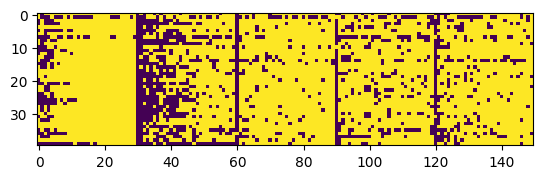

In [40]:
plt.imshow(rwdrate)

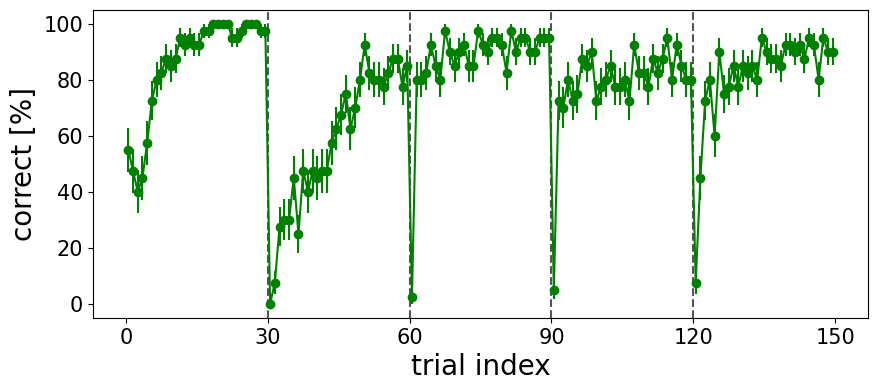

In [53]:
plt.figure(figsize = (10,4))
for i in range(1,int(trialnum/hp.swblock)):
    plt.plot([hp.swblock*i-0.5,hp.swblock*i-0.5], [-5,105], "--",color = "#555555")
plt.errorbar(np.arange(trialnum), np.nanmean(rwdrate,0)*100, 100*np.nanstd(rwdrate,0)/np.sqrt(num),fmt="go-")
plt.xlabel("trial index", fontsize = 20)
plt.ylabel("correct [%]", fontsize = 20)
plt.xticks(np.arange(-0.5,trialnum+1,30),np.arange(0,trialnum+1,30), fontsize = 15)
plt.yticks(fontsize = 15) 
plt.ylim([-5,105])
plt.savefig("./figure/dropby_alternative_correct.png", bbox_inches = "tight")

In [44]:
inflen = np.zeros((num,trialnum))*np.nan
for x in range(num):
    tmp = [int((len(allresult[x][r][-1]["HCtrans"])-1)/2) for r in range(len(allresult[x]))]
    inflen[x,:len(tmp)] = tmp

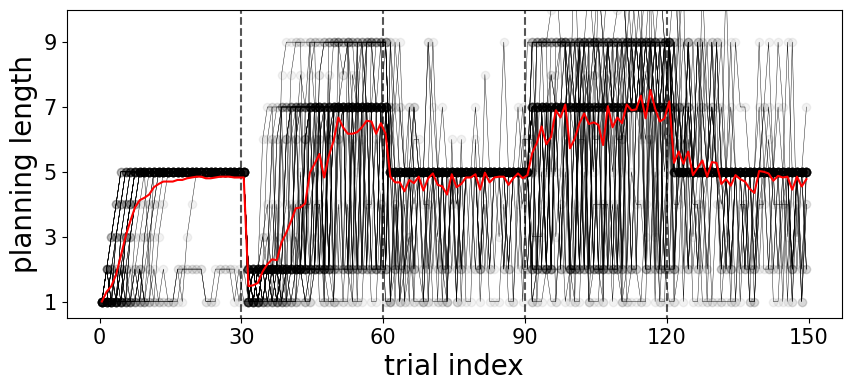

In [55]:
plt.figure(figsize = (10,4))
for i in range(1,int(trialnum/hp.swblock)):
    plt.plot([hp.swblock*i-0.5,hp.swblock*i-0.5], [0,10], "--",color = "#555555")
for i in range(num):
    plt.plot(np.arange(trialnum), inflen[i,:]+np.random.rand(trialnum)*0, "ko-", linewidth = 0.3, markerfacecolor = (0,0,0,0.05))    
plt.plot(np.arange(trialnum), np.nanmean(inflen,0), "r")
plt.xlabel("trial index", fontsize = 20)
plt.ylabel("planning length", fontsize = 20)
plt.xticks(np.arange(-0.5,trialnum+1,30), np.arange(0,trialnum + 1,30), fontsize = 15)
plt.yticks(np.arange(1,10,2),fontsize = 15)
plt.ylim([.5,10])
plt.savefig("./figure/dropby_alternative_inflen.png", bbox_inches = "tight")

In [47]:
for x in range(2):
    allHCs, allinfs = [], []
    if len(allresult[x]) != trialnum:
        continue
    for y in range(trialnum):
        HCs = []
        for z in range(len(allresult[x][y])):
            tmp = copy.deepcopy(allresult[x][y][z]["HCtrans"])
            if len(tmp) % 2 == 1:
                tmp = tmp[1:]
            arg = np.isin(tmp, HCs)
            HCs.extend(list(tmp[~arg]))
            tmp = allresult[x][y][z]["infcond"]
            if z == 0:
                infs = copy.deepcopy(tmp)
            elif infs[-1] == tmp[0]:
                infs.extend(tmp[1:])
            elif infs[-1] == tmp[-1]:
                continue
            else:
                print(x,y,z,tmp, infs, len(HCs))
        if HCs[0] == HCs[-1]:
            HCs = HCs[:-1]
        if infs[0] == infs[-1]:
            infs = infs[:-1]
        HCs = HCs[:len(infs)*2]
        allHCs.append(HCs)
        allinfs.append(infs)

0 0 1 [2.0] [1.0] 4
0 0 2 [3.0] [1.0] 6
0 0 3 [2.0] [1.0] 8
0 1 2 [4.0, 1.0] [1.0, 2.0] 6
0 31 1 [3.0] [1.0, 2.0, 3.0, 2.0] 10
0 31 3 [3.0] [1.0, 2.0, 3.0, 2.0] 14
0 31 5 [4.0, 1.0] [1.0, 2.0, 3.0, 2.0] 18
0 64 1 [3.0] [1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 3.0, 2.0] 18
0 64 3 [4.0, 1.0] [1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 3.0, 2.0] 22
0 144 1 [3.0] [1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 3.0, 2.0, 3.0, 2.0] 22
0 144 3 [4.0, 1.0] [1.0, 2.0, 3.0, 2.0, 3.0, 2.0, 3.0, 2.0, 3.0, 2.0] 26
1 0 1 [2.0] [1.0] 4
1 0 2 [3.0] [1.0] 6
1 0 3 [2.0] [1.0] 7
1 1 2 [4.0, 1.0] [1.0, 2.0] 6
1 33 4 [3.0] [1.0, 2.0, 3.0, 2.0] 9
1 33 6 [3.0] [1.0, 2.0, 3.0, 2.0] 13
1 33 8 [4.0, 1.0] [1.0, 2.0, 3.0, 2.0] 17
1 35 6 [4.0, 1.0] [1.0, 2.0, 3.0, 2.0, 3.0, 2.0] 13


In [48]:
mat = np.zeros((2*7, 7))
for i in range(7):
    mat[2*i:2*i+2,i] = 1

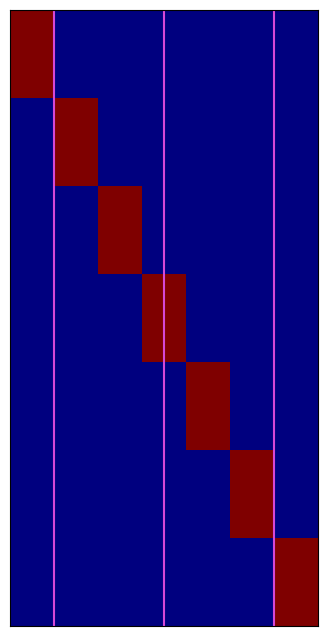

In [49]:
plt.figure(figsize = (4,8))
plt.imshow(mat, cmap = "jet")
plt.plot(np.ones(2)*0.5,[-0.5,13.5], color = "#D648D6")
plt.plot(np.ones(2)*3,[-0.5,13.5], color = "#D648D6")
plt.plot(np.ones(2)*5.5,[-0.5,13.5], color = "#D648D6")
plt.tick_params(left = False, right = False , labelleft = False ,
                labelbottom = False, bottom = False)
plt.savefig("./figure/dropby_alternative_firing.png", bbox_inches = "tight")